<Figure size 1400x600 with 0 Axes>

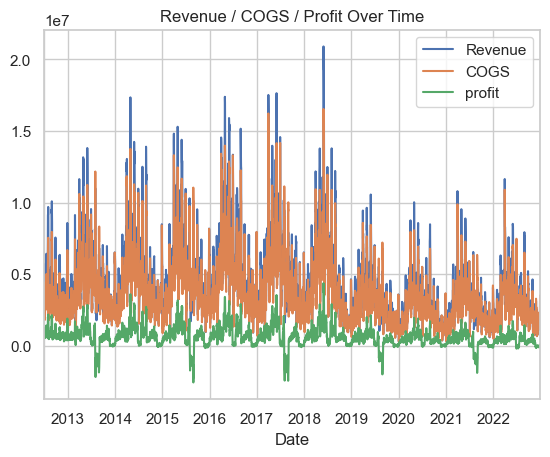

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

sales = pd.read_csv("data/sales.csv", parse_dates=['Date'])

sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.to_period('M')

sales['profit'] = sales['Revenue'] - sales['COGS']

# Visualization
plt.figure(figsize=(14, 6))

sales.set_index('Date')[['Revenue', 'COGS', 'profit']].plot()

plt.title("Revenue / COGS / Profit Over Time")
plt.show()

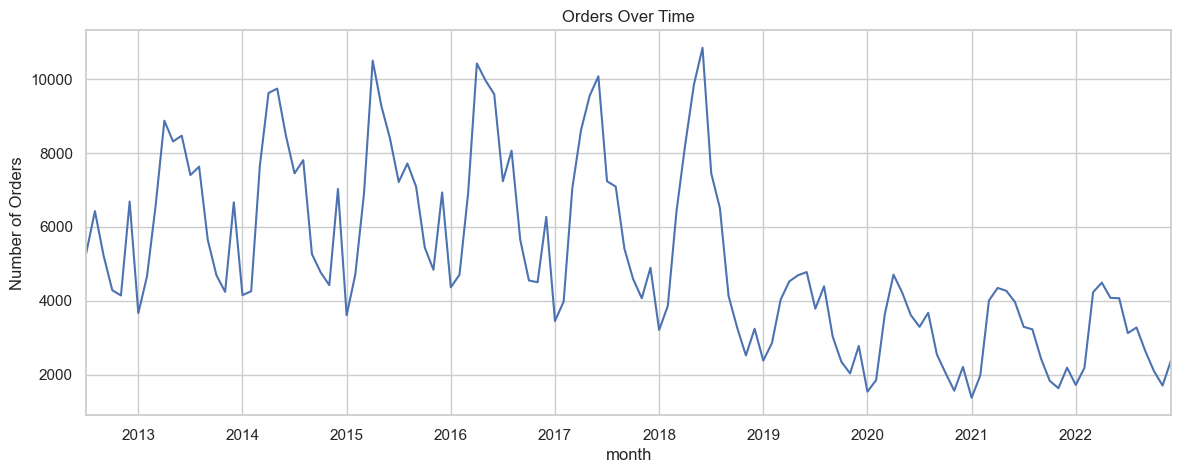

In [8]:
orders = pd.read_csv("data/orders.csv", parse_dates=['order_date'])

orders['month'] = orders['order_date'].dt.to_period('M')

orders_ts = orders.groupby('month').size()

plt.figure(figsize=(14, 5))
orders_ts.plot()

plt.title("Orders Over Time")
plt.ylabel("Number of Orders")
plt.show()

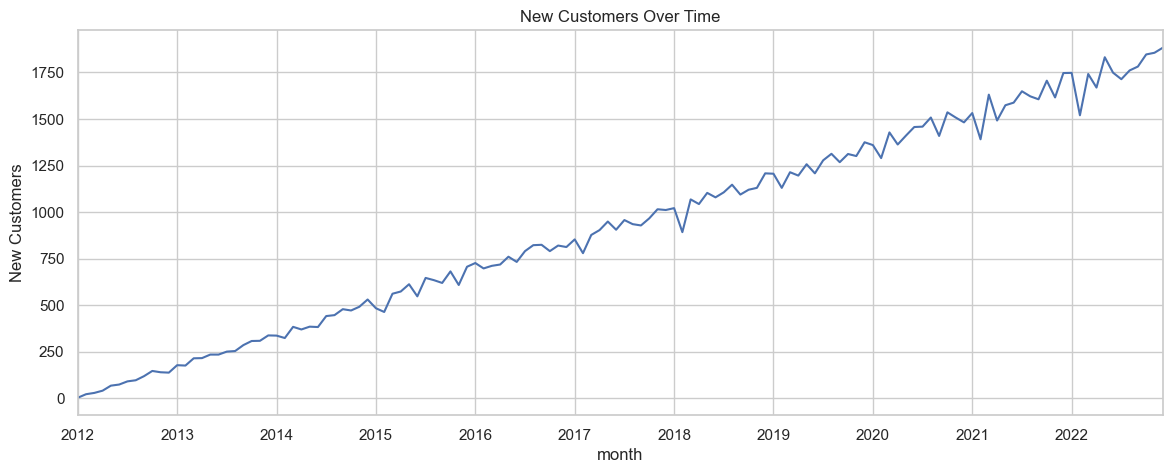

In [9]:
customers = pd.read_csv("data/customers.csv", parse_dates=['signup_date'])

customers['month'] = customers['signup_date'].dt.to_period('M')

signup_ts = customers.groupby('month').size()

plt.figure(figsize=(14, 5))
signup_ts.plot()

plt.title("New Customers Over Time")
plt.ylabel("New Customers")
plt.show()

<Figure size 1400x500 with 0 Axes>

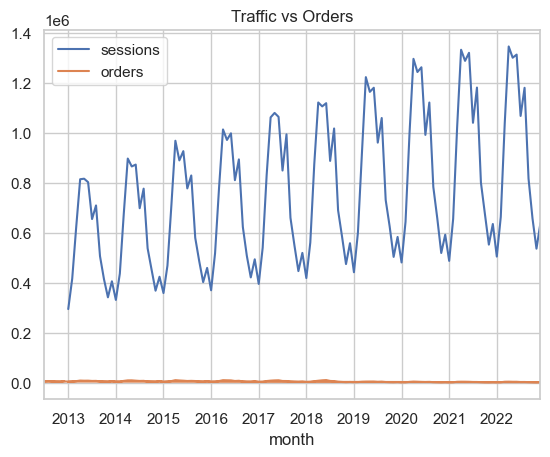

In [10]:
traffic = pd.read_csv("data/web_traffic.csv", parse_dates=['date'])

traffic['month'] = traffic['date'].dt.to_period('M')
traffic_ts = traffic.groupby('month')['sessions'].sum()

orders_ts = orders.groupby('month').size()

df = pd.concat([traffic_ts, orders_ts], axis=1)
df.columns = ['sessions', 'orders']

# Visualization
plt.figure(figsize=(14, 5))
df.plot()

plt.title("Traffic vs Orders")
plt.show()

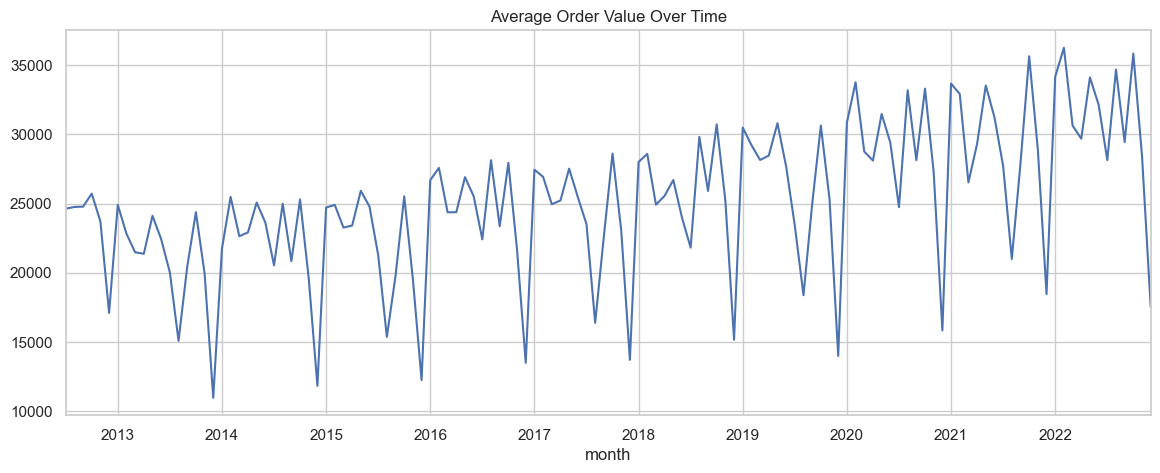

In [11]:
payments = pd.read_csv("data/payments.csv")

order_value = payments.groupby('order_id')['payment_value'].sum()

orders = orders.merge(order_value, on='order_id')

orders['month'] = orders['order_date'].dt.to_period('M')

aov_ts = orders.groupby('month')['payment_value'].mean()

plt.figure(figsize=(14, 5))
aov_ts.plot()

plt.title("Average Order Value Over Time")
plt.show()

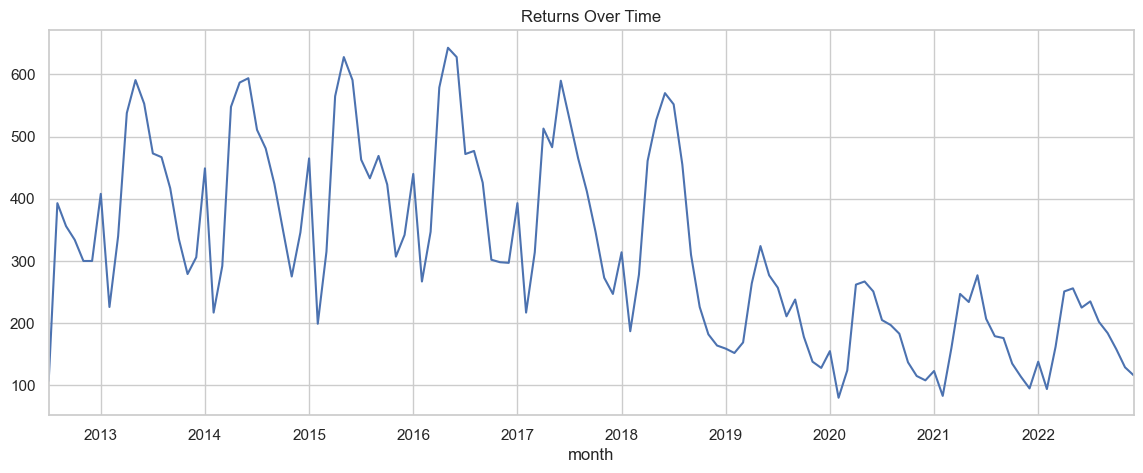

In [12]:
returns = pd.read_csv("data/returns.csv", parse_dates=['return_date'])

returns['month'] = returns['return_date'].dt.to_period('M')

returns_ts = returns.groupby('month').size()

plt.figure(figsize=(14, 5))
returns_ts.plot()

plt.title("Returns Over Time")
plt.show()

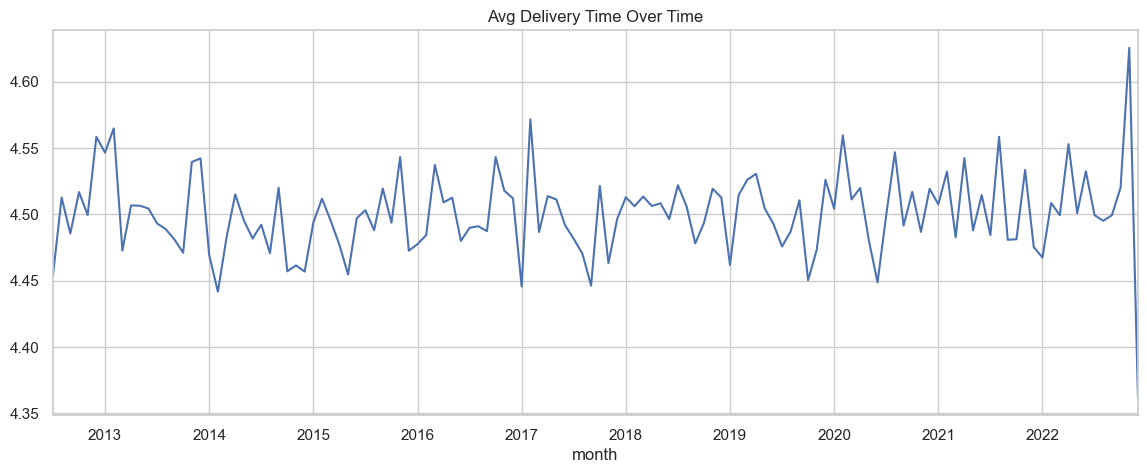

In [13]:
ship = pd.read_csv("data/shipments.csv", parse_dates=['ship_date', 'delivery_date'])

ship['delivery_time'] = (ship['delivery_date'] - ship['ship_date']).dt.days
ship['month'] = ship['ship_date'].dt.to_period('M')

delivery_ts = ship.groupby('month')['delivery_time'].mean()

plt.figure(figsize=(14, 5))
delivery_ts.plot()

plt.title("Avg Delivery Time Over Time")
plt.show()

<Figure size 1400x500 with 0 Axes>

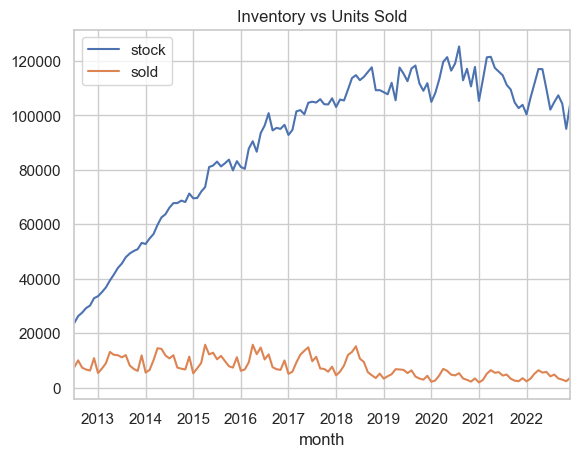

In [14]:
inv = pd.read_csv("data/inventory.csv")

inv['month'] = pd.to_datetime(inv['snapshot_date']).dt.to_period('M')

stock_ts = inv.groupby('month')['stock_on_hand'].sum()
sold_ts = inv.groupby('month')['units_sold'].sum()

df = pd.concat([stock_ts, sold_ts], axis=1)
df.columns = ['stock', 'sold']

plt.figure(figsize=(14, 5))
df.plot()

plt.title("Inventory vs Units Sold")
plt.show()

C:\Users\nguye\AppData\Local\Temp\ipykernel_17768\2324310688.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  oi = pd.read_csv("data/order_items.csv")


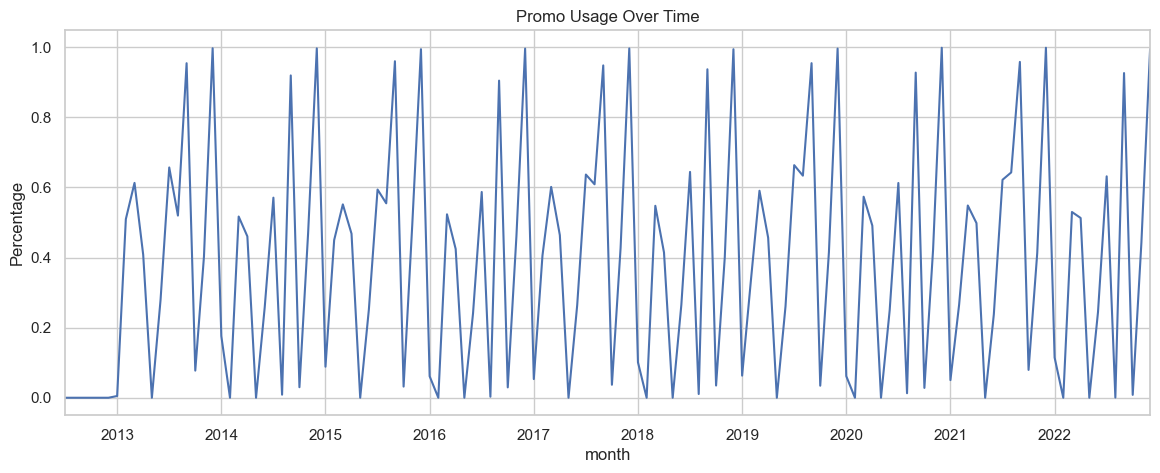

In [15]:
oi = pd.read_csv("data/order_items.csv")
orders = pd.read_csv("data/orders.csv", parse_dates=['order_date'])

df = oi.merge(orders[['order_id', 'order_date']], on='order_id')

df['month'] = df['order_date'].dt.to_period('M')

df['has_promo'] = df['promo_id'].notna()

promo_ts = df.groupby('month')['has_promo'].mean()

plt.figure(figsize=(14, 5))
promo_ts.plot()

plt.title("Promo Usage Over Time")
plt.ylabel("Percentage")
plt.show()

Mọi sự tập trung dồn về năm 2019, tại đó Revenue - profit  đều giảm
Nhưng trái lại new_customer - average tăng
Vậy ta sẽ kiểm tra đã có chuyện gì xảy ra ở năm 2019